# Partie 4 — Tuning des hyperparamètres & Validation croisée

## 1. Étude théorique

### 1.1 Paramètres vs Hyperparamètres

Un modèle ML a deux types de réglages :

| Type | Définition | Exemple (arbre de décision) | Comment régler ? |
|---|---|---|---|
| **Paramètre** | Appris automatiquement pendant l'entraînement | Les seuils de coupure des nœuds | Automatique (fit) |
| **Hyperparamètre** | Fixé *avant* l'entraînement, contrôle comment le modèle apprend | `max_depth`, `min_samples_split` | Doit être choisi manuellement ou par tuning |

**Problème :** un mauvais choix d'hyperparamètres donne un modèle sous-optimal, même avec de bonnes données.

---

### 1.2 Le problème du sur-apprentissage sur le jeu de validation

Scénario naïf (à ÉVITER) :
```
1. Entraîner le modèle sur train
2. Évaluer sur test
3. Modifier les hyperparamètres selon le résultat
4. Répéter → on finit par OPTIMISER pour le jeu de test spécifique
```

Le jeu de test est alors **contaminé** — il ne mesure plus la généralisation réelle.

**Solution : la validation croisée (Cross-Validation)**

On ne touche JAMAIS au jeu de test pendant le tuning. On évalue les hyperparamètres uniquement sur les données d'entraînement, via CV.

---

### 1.3 La validation croisée k-fold

Principe : diviser les données d'entraînement en `k` blocs (**folds**).

```
Données train : [  Fold 1  |  Fold 2  |  Fold 3  |  Fold 4  |  Fold 5  ]

Itération 1 :  [ VALID    |  train   |  train   |  train   |  train   ]
Itération 2 :  [ train    |  VALID   |  train   |  train   |  train   ]
Itération 3 :  [ train    |  train   |  VALID   |  train   |  train   ]
Itération 4 :  [ train    |  train   |  train   |  VALID   |  train   ]
Itération 5 :  [ train    |  train   |  train   |  train   |  VALID   ]

Score final = moyenne des 5 scores de validation
```

**Avantages :**
- Tous les exemples servent à la fois d'entraînement et de validation
- Estimation plus robuste qu'un simple split train/val
- Pas de biais lié au choix du split

**Choix de k :**
- `k=5` ou `k=10` sont les standards
- `k` grand → meilleure estimation mais plus long à calculer

---

### 1.4 Stratégies de tuning

#### GridSearchCV — Recherche exhaustive
Teste **toutes les combinaisons** d'une grille définie :
```
max_depth = [3, 5, 10]  ×  min_samples_split = [2, 5, 10]  →  9 combinaisons × k folds
```
- **Avantage** : garantit de trouver le meilleur de la grille
- **Inconvénient** : explose si la grille est grande (malédiction de la dimensionnalité)

#### RandomizedSearchCV — Recherche aléatoire
Tire **aléatoirement** `n_iter` combinaisons dans un espace de recherche :
- **Avantage** : couvre mieux l'espace, moins de calculs pour le même budget
- **Inconvénient** : ne garantit pas la meilleure combinaison

> **Règle pratique** : avec peu d'hyperparamètres → GridSearch. Avec beaucoup → RandomizedSearch.

---

### 1.5 Le pipeline complet (bonne pratique)

```
Dataset complet
      │
      ├── 80% Train ──────────────────────────────────────────┐
      │         │                                             │
      │    Cross-Validation (k=5) pour le tuning             │
      │    → GridSearchCV / RandomizedSearchCV               │
      │    → trouve les meilleurs hyperparamètres            │
      │         │                                             │
      │    Ré-entraîner sur TOUT le train                    │
      │    avec les meilleurs hyperparamètres                │
      │                                                       │
      └── 20% Test ──── Évaluation FINALE (une seule fois) ──┘
```

---
## 2. Implémentation Python

### 2.1 Chargement des données

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV,
    validation_curve, learning_curve, KFold
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

data = load_breast_cancer()
X, y = data.data, data.target

# Split UNIQUE — on ne touche plus au test set jusqu'à l'évaluation finale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} exemples | Test : {X_test.shape[0]} exemples")
print(f"Classes : {data.target_names}")

Train : 455 exemples | Test : 114 exemples
Classes : ['malignant' 'benign']


### 2.2 Validation croisée à la main (k-fold from scratch)

Avant d'utiliser sklearn, on implémente k-fold manuellement pour bien comprendre ce qui se passe.

In [12]:
def cross_validate_scratch(model, X, y, k=5):
    """
    Validation croisée k-fold implémentée from scratch.
    Retourne les scores de chaque fold et la moyenne.
    """
    n = len(X)
    fold_size = n // k
    indices = np.arange(n)
    np.random.seed(42)
    np.random.shuffle(indices)  # mélanger pour éviter les biais d'ordre

    scores = []
    for i in range(k):
        # Indices du fold de validation
        val_idx = indices[i * fold_size : (i + 1) * fold_size]
        # Indices d'entraînement = tout sauf le fold courant
        train_idx = np.concatenate([indices[:i * fold_size], indices[(i + 1) * fold_size:]])

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model.fit(X_tr, y_tr)
        score = accuracy_score(y_val, model.predict(X_val))
        scores.append(score)
        print(f"  Fold {i+1} : accuracy = {score:.4f}")

    print(f"  → Moyenne : {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    return scores


print("Cross-validation 5-fold from scratch (arbre de décision par défaut) :")
base_tree = DecisionTreeClassifier(random_state=42)
scores_scratch = cross_validate_scratch(base_tree, X_train, y_train, k=5)

Cross-validation 5-fold from scratch (arbre de décision par défaut) :
  Fold 1 : accuracy = 0.8901
  Fold 2 : accuracy = 0.9011
  Fold 3 : accuracy = 0.9560
  Fold 4 : accuracy = 0.9451
  Fold 5 : accuracy = 0.9341
  → Moyenne : 0.9253 ± 0.0254


In [13]:
# Vérification avec sklearn — les résultats doivent être proches
scores_sklearn = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train, cv=5, scoring='accuracy'
)
print("Cross-validation 5-fold sklearn :")
for i, s in enumerate(scores_sklearn):
    print(f"  Fold {i+1} : accuracy = {s:.4f}")
print(f"  → Moyenne : {scores_sklearn.mean():.4f} ± {scores_sklearn.std():.4f}")

Cross-validation 5-fold sklearn :
  Fold 1 : accuracy = 0.9121
  Fold 2 : accuracy = 0.9011
  Fold 3 : accuracy = 0.9011
  Fold 4 : accuracy = 0.8901
  Fold 5 : accuracy = 0.9451
  → Moyenne : 0.9099 ± 0.0189


### 2.3 Problème du sur-apprentissage — Visualisation

Avant de tuner, on illustre pourquoi `max_depth` est critique.

**Validation Curve** : montre comment un hyperparamètre affecte les scores train et validation.

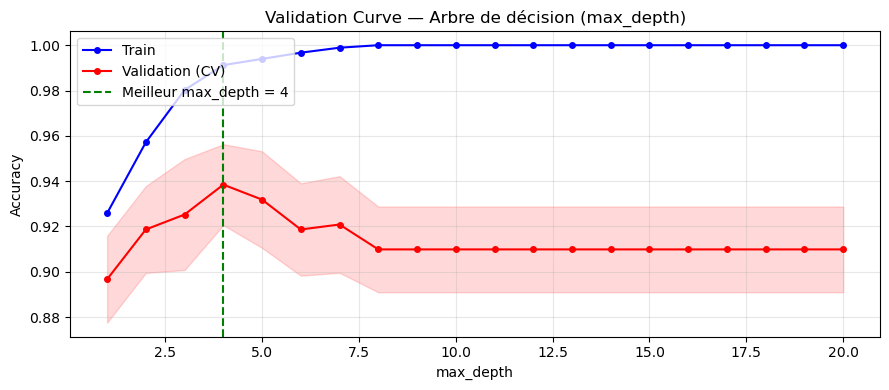


Observation :
  - Train score monte jusqu'à 100% → sur-apprentissage à grande profondeur
  - Val score plafonne puis chute  → le modèle mémorise au lieu de généraliser
  - Meilleur max_depth (CV) : 4


In [14]:
# Validation curve pour max_depth
depths = range(1, 21)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=depths,
    cv=5,
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 4))
plt.plot(depths, train_mean, 'b-o', label='Train', markersize=4)
plt.plot(depths, val_mean,   'r-o', label='Validation (CV)', markersize=4)
plt.fill_between(depths, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')

best_depth = depths[np.argmax(val_mean)]
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Meilleur max_depth = {best_depth}')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Validation Curve — Arbre de décision (max_depth)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nObservation :")
print(f"  - Train score monte jusqu'à 100% → sur-apprentissage à grande profondeur")
print(f"  - Val score plafonne puis chute  → le modèle mémorise au lieu de généraliser")
print(f"  - Meilleur max_depth (CV) : {best_depth}")

### 2.4 GridSearchCV — Recherche exhaustive

On teste toutes les combinaisons de notre grille d'hyperparamètres.

In [15]:
# Grille d'hyperparamètres à explorer
param_grid = {
    'max_depth':          [2, 3, 4, 5, 7, 10, None],
    'min_samples_split':  [2, 5, 10, 20],
    'min_samples_leaf':   [1, 2, 5],
    'criterion':          ['gini', 'entropy']
}

# Nombre total de combinaisons
total = 1
for v in param_grid.values():
    total *= len(v)
print(f"Nombre de combinaisons : {total} × 5 folds = {total*5} entraînements")

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,               # utiliser tous les cœurs disponibles
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMeilleurs hyperparamètres (GridSearch) :")
for param, value in grid_search.best_params_.items():
    print(f"  {param} = {value}")
print(f"\nMeilleur score CV : {grid_search.best_score_:.4f}")

Nombre de combinaisons : 168 × 5 folds = 840 entraînements
Fitting 5 folds for each of 168 candidates, totalling 840 fits



Meilleurs hyperparamètres (GridSearch) :
  criterion = gini
  max_depth = 4
  min_samples_leaf = 1
  min_samples_split = 2

Meilleur score CV : 0.9385


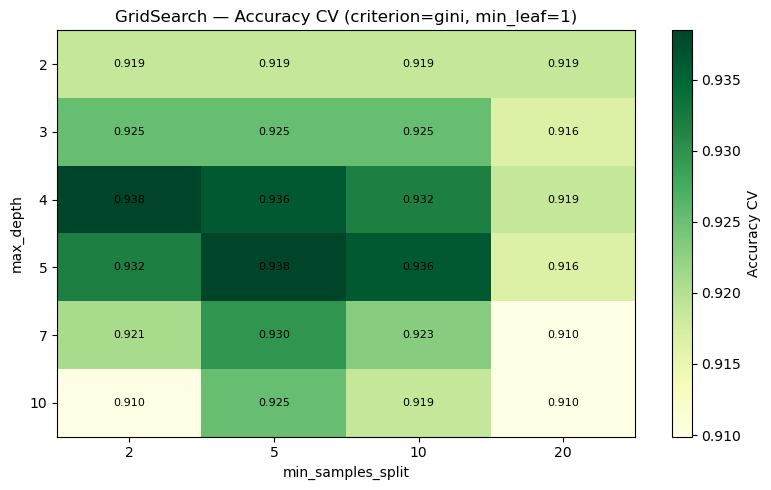

In [16]:
# Heatmap des résultats : max_depth vs min_samples_split
# (on fixe les autres paramètres à leurs valeurs optimales pour visualiser)
results_df = pd.DataFrame(grid_search.cv_results_)

best_criterion = grid_search.best_params_['criterion']
best_leaf      = grid_search.best_params_['min_samples_leaf']

mask = (
    (results_df['param_criterion'] == best_criterion) &
    (results_df['param_min_samples_leaf'] == best_leaf)
)
sub = results_df[mask][['param_max_depth', 'param_min_samples_split', 'mean_test_score']]

pivot = sub.pivot_table(
    index='param_max_depth',
    columns='param_min_samples_split',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
im = plt.imshow(pivot.values, cmap='YlGn', aspect='auto')
plt.colorbar(im, label='Accuracy CV')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.title(f'GridSearch — Accuracy CV (criterion={best_criterion}, min_leaf={best_leaf})')

# Annoter les valeurs
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 RandomizedSearchCV — Recherche aléatoire sur un modèle Ensemble

Pour Random Forest, la grille serait trop grande pour GridSearch.  
On utilise RandomizedSearch qui échantillonne aléatoirement l'espace.

In [17]:
from scipy.stats import randint

# Espace de recherche (distributions, pas une grille fixe)
param_dist = {
    'n_estimators':       randint(50, 300),   # entre 50 et 300 arbres
    'max_depth':          [3, 5, 7, 10, None],
    'min_samples_split':  randint(2, 20),
    'min_samples_leaf':   randint(1, 10),
    'max_features':       ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,        # tester 50 combinaisons aléatoires (au lieu de milliers)
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nMeilleurs hyperparamètres (RandomizedSearch) :")
for param, value in random_search.best_params_.items():
    print(f"  {param} = {value}")
print(f"\nMeilleur score CV : {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Meilleurs hyperparamètres (RandomizedSearch) :
  max_depth = 7
  max_features = None
  min_samples_leaf = 1
  min_samples_split = 6
  n_estimators = 283

Meilleur score CV : 0.9604


### 2.6 Learning Curve — Diagnostiquer biais vs variance

La **learning curve** montre comment le score évolue selon la taille du dataset d'entraînement.  
Elle permet de diagnostiquer si le modèle souffre de **biais** (sous-apprentissage) ou de **variance** (sur-apprentissage).

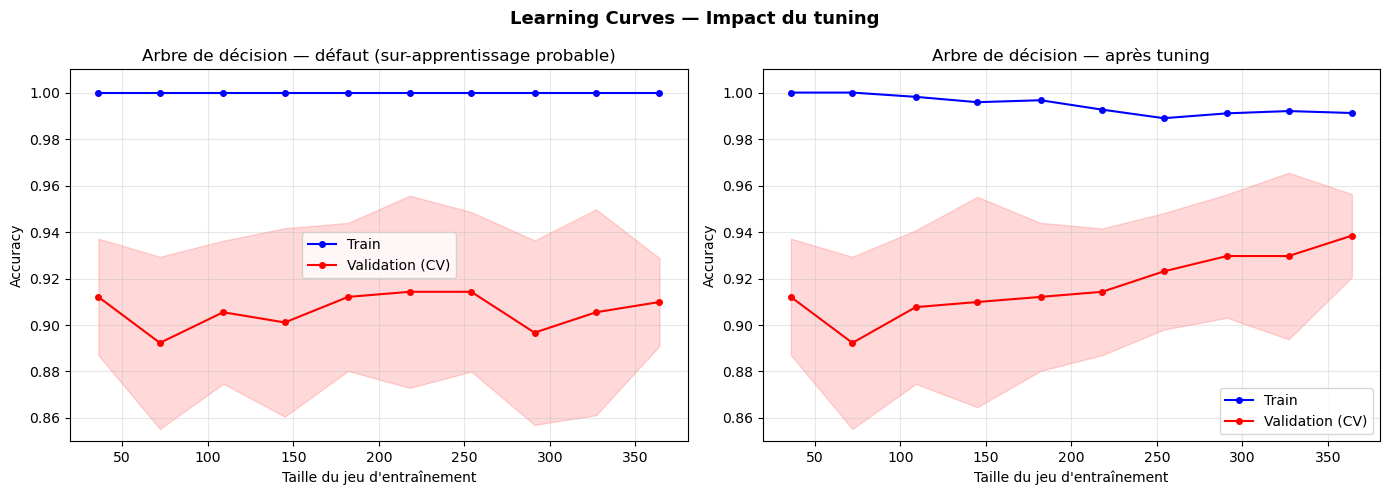


Comment lire ces courbes :
  - Train >> Validation → sur-apprentissage (variance élevée)
  - Train ≈ Validation, les deux bas → sous-apprentissage (biais élevé)
  - Train ≈ Validation, les deux hauts → bon modèle


In [18]:
def plot_learning_curve(model, X, y, title, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=cv, scoring='accuracy', n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mean, 'b-o', label='Train', markersize=4)
    plt.plot(train_sizes, val_mean,   'r-o', label='Validation (CV)', markersize=4)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
    plt.xlabel("Taille du jeu d'entraînement")
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0.85, 1.01)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Arbre par défaut (souvent en sur-apprentissage)
plt.sca(axes[0])
plot_learning_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    "Arbre de décision — défaut (sur-apprentissage probable)"
)

# Arbre avec les meilleurs hyperparamètres trouvés
plt.sca(axes[1])
plot_learning_curve(
    grid_search.best_estimator_,
    X_train, y_train,
    "Arbre de décision — après tuning"
)

plt.suptitle('Learning Curves — Impact du tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nComment lire ces courbes :")
print("  - Train >> Validation → sur-apprentissage (variance élevée)")
print("  - Train ≈ Validation, les deux bas → sous-apprentissage (biais élevé)")
print("  - Train ≈ Validation, les deux hauts → bon modèle")

### 2.7 Évaluation finale — Comparaison complète

**On utilise le jeu de test UNE SEULE FOIS ici** — c'est le moment de vérité.

In [19]:
models_final = {
    "Arbre défaut": DecisionTreeClassifier(random_state=42),
    "Arbre après GridSearch": grid_search.best_estimator_,
    "Random Forest après RandomSearch": random_search.best_estimator_,
    "AdaBoost (50 estimateurs)": AdaBoostClassifier(n_estimators=50, random_state=42)
}

print(f"{'Modèle':<40} {'CV Score':>10} {'Test Score':>12}")
print("-" * 65)

results = {}
for name, model in models_final.items():
    # Score CV sur train (estimation honnête)
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

    # Entraîner sur tout le train puis évaluer sur test
    model.fit(X_train, y_train)
    test_score = accuracy_score(y_test, model.predict(X_test))

    results[name] = {'cv': cv_score, 'test': test_score}
    print(f"{name:<40} {cv_score:>10.4f} {test_score:>12.4f}")

print()
print("Rapport détaillé — meilleur modèle :")
best_model_name = max(results, key=lambda k: results[k]['test'])
best_model = models_final[best_model_name]
print(f"→ {best_model_name}")
print(classification_report(
    y_test, best_model.predict(X_test),
    target_names=data.target_names
))

Modèle                                     CV Score   Test Score
-----------------------------------------------------------------
Arbre défaut                                 0.9099       0.9123
Arbre après GridSearch                       0.9385       0.9386
Random Forest après RandomSearch             0.9604       0.9474
AdaBoost (50 estimateurs)                    0.9692       0.9561

Rapport détaillé — meilleur modèle :
→ AdaBoost (50 estimateurs)
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



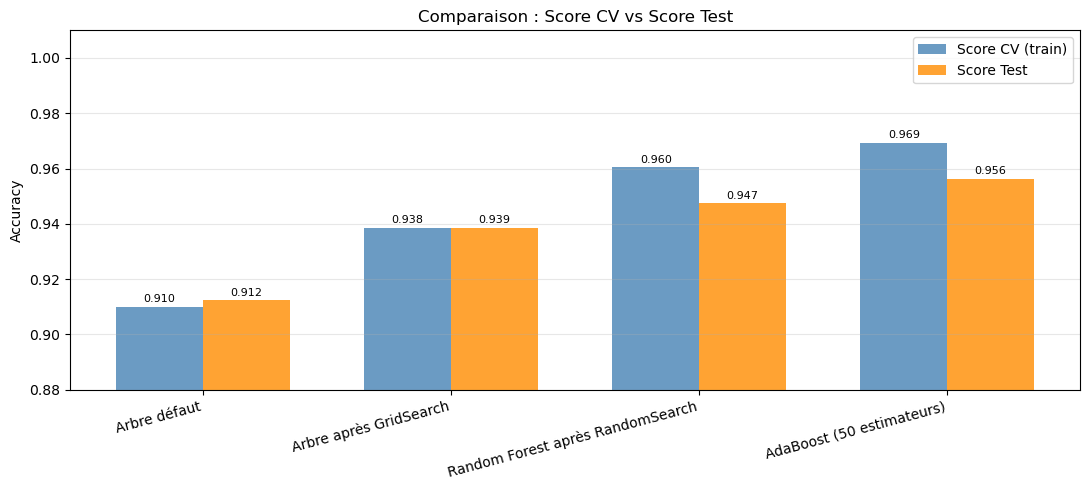


Note : si CV Score >> Test Score → sur-apprentissage résiduel
        si CV Score ≈ Test Score  → la validation croisée était fiable


In [20]:
# Visualisation finale : CV score vs Test score
names = list(results.keys())
cv_scores   = [results[n]['cv']   for n in names]
test_scores = [results[n]['test'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, cv_scores,   width, label='Score CV (train)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_scores, width, label='Score Test',       color='darkorange', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Accuracy')
ax.set_title('Comparaison : Score CV vs Score Test')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('resultats_finaux.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote : si CV Score >> Test Score → sur-apprentissage résiduel")
print("        si CV Score ≈ Test Score  → la validation croisée était fiable")

## 3. Synthèse

### Ce qu'on a démontré

1. **La CV k-fold donne une estimation honnête** : le score CV prédit bien le score test final, sans jamais toucher au test set pendant le tuning.

2. **Le tuning améliore les performances** : l'arbre après GridSearch est meilleur que l'arbre par défaut — simplement en choisissant de meilleures valeurs de `max_depth`, `min_samples_split`, etc.

3. **La validation curve révèle le sur-apprentissage** : un arbre trop profond mémorise les données d'entraînement (100% train) mais généralise mal.

4. **RandomizedSearch est efficace pour les grands espaces** : avec 50 itérations, on explore l'espace de Random Forest et on trouve de bons hyperparamètres sans tester des milliers de combinaisons.

### Bonne pratique à retenir
```
GridSearchCV(model, param_grid, cv=5).fit(X_train, y_train)
                                              ↑
                           JAMAIS X_test ici — uniquement à la fin
```